# Segmentation

Segmentation is a fundamental task in pointcloud processing, where **the goal is to partition a pointcloud into meaningful regions or segments**. This notebooks covers "traditional" or geometric segmentation techniques.

The first part focuses on **surface segmentation**, which involves isolating and potentially identifying different surfaces within a pointcloud, with three of the most popular surface segmentation algorithms: **Region Growing, the Hough Transform, and RANSAC**.

The second part is about **object segmentation** and isolating parts of the pointcloud consisting of distinct objects using groups of close points. This is often referred as **graph-based segmentation** and used as a baseline for more advanced techniques such as object recognition.

Note that other types of segmentation tasks are not described in this notebook. These include more advanced *instance segmentation* (separating individual instances of objects) and *semantic segmentation* (assigning semantic labels to each point). These tasks often rely on machine learning and deep learning models and are covered in the next notebooks.


In [1]:
# Necessary imports
import numpy as np
from scipy import ndimage
from scipy.spatial import KDTree
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt

# Load pointcloud
data = np.loadtxt("./data/indoor_scene.xyz")
points, colors = data[:, :3], data[:, 6:]
# Build the kd-tree (for neighbor search) once
kdtree = KDTree(points)

For the sake of illustration, let's consider a synthetic pointcloud representing an indoor scene, represented below. This scene is composed of 8 "objects": 1 floor (grey), 2 walls (beige), 1 drawer (brown), 1 pipe (grey), 1 ball (blue), 1 stool (red), and 1 plant in a pot (terracotta and green). Each of these object having one or more surfaces.


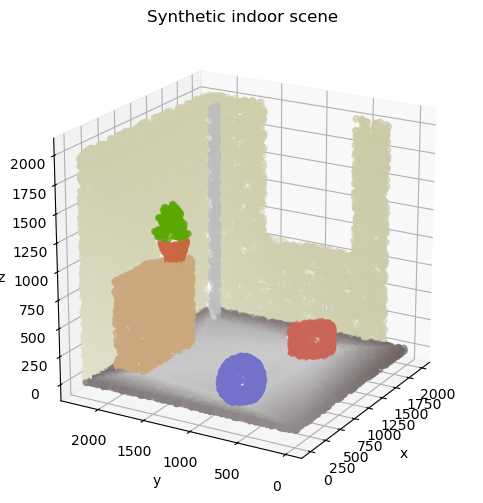

In [2]:
# Plot original pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          c=colors)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_box_aspect([1, 1, 1])
ax.view_init(20, 210)
ax.set_title("Synthetic indoor scene")
plt.show()


## Surface Segmentation

Surface segmentation divides a pointcloud into separate regions that represent individual surfaces by grouping points with similar geometric properties, such as location, orientation, or shape.

### Region Growing

One of the most common approaches for surface segmentation is **Region Growing**. This algorithm (which is also widely used in image processing) works by **iteratively aggregating neighboring points with similar properties** in a bottom-up manner.

It consists of just two steps:

1. **Region initialization** by selecting a starting element (or *seed*).

2. **Region growth** by progressively incorporating neighboring elements that satisfy a predefined similarity criterion.

The growth process stops when no neighboring elements can be added to the current region. The procedure is then repeated with a new seed until all points in the pointcloud have been assigned to a region, resulting in $n$ segmented regions after $n$ iterations.

Note that **Region Growing requires both a similarity criterion and a neighborhood structure**. Similarity can be evaluated using one or several attributes, such as normals, colors, or curvatures, while neighborhoods may be defined using $k$-nearest neighbors, a fixed-radius, or other connectivity relationships.

A popular choice for segmenting a pointcloud into smooth surface patches relies on a *smoothness constraint* based on the angular variation between local surface normals computed within a $k$-nearest neighborhood \cite{rabbani2006segmentation}. Normals are estimated by local plane fitting, and neighboring points are grouped together when the angle between their normals is sufficiently small. The fitting residual (or alternatively the *curvature change* $C_{\lambda}$) helps detect points located on edges (i.e., strongly curved areas) and is used both to select seed points and to stop region growth near surface boundaries.

The implementation below computes the normals and residuals using $k$ nearest neighbors for all points at once and uses vectorized operations for execution speed. This may be memory intensive for large pointclouds, so consider switching to batch processing if memory becomes an issue.

In [3]:
def compute_normals_residuals(points, neighbor_finder):
    """Compute normals and residuals from tangent plane estimation."""

    # Local connectivity with knn
    inds = neighbor_finder(points) # (N, k)
    neighbors = points[inds]
    # Local plane fitting
    neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
    cov = (neighbors.transpose(0, 2, 1) @ neighbors)  # (N, 3, 3)
    eigenvalues, eigenvectors = np.linalg.eigh(cov) # (N, 3), (N, 3, 3)
    normals = eigenvectors[:,:,0]
    residuals = eigenvalues[:, 0]

    return normals, residuals

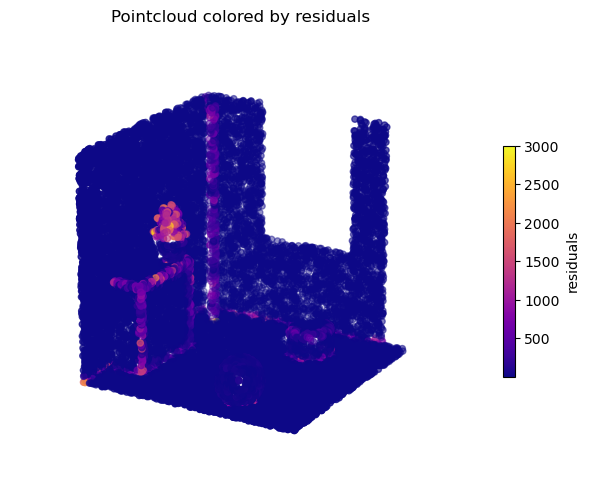

In [4]:
# Compute and plot residuals
neighbor_finder = lambda points: kdtree.query(points, 10)[1]
# for spherical neighborhood: return kdtree.query_ball_point(x, r=10.) 
normals, residuals = compute_normals_residuals(points, neighbor_finder)

# Plot pointcloud colored by residuals
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          c=residuals, cmap="plasma")
cbar = fig.colorbar(p, shrink=0.5)
cbar.set_label('residuals')
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=20, azim=210)
ax.set_title("Pointcloud colored by residuals")
plt.show()

The estimated normals and residuals are then used to drive the region-growing process. The algorithm starts from a seed point, chosen among the points with the lowest residuals. The region is then iteratively expanded according to the following rules:

1. A neighboring point $p_{j}$​ is added to the current region if the angle between its normal and that of $p_{i}$​ is smaller than a given threshold:
\begin{equation*}
    |n_i \cdot n_j| > \cos(\theta_{th})
\end{equation*}

2. The point $p_{j}$​ is selected for further growth only if its residual is below a given threshold: 
\begin{equation*}
    r_j < r_{th}
\end{equation*}

In the first expression, the absolute value of the dot product accounts for the sign ambiguity of estimated normals, whose orientation is only defined up to 180°. Normals are also assumed to be unit vectors.

The angular threshold $\theta_{th}$​ has a direct geometric interpretation, while the residual threshold $r_{th}$ is somewhat less intuitive to tune. $r_{th}$​ is then typically defined as a relative threshold with respect to the distribution of residual values in the pointcloud. For this reason, some implementations use the *curvature change* $C_{\lambda}$​ instead, as it is normalized and generally easier to interpret and tune.

The neighborhood size and threshold values directly control the granularity of the segmentation. Smaller neighborhoods and stricter thresholds (i.e., lower values of $\theta_{th}$​ and $r_{th}$​) produce more conservative region growth and tend to increase over-segmentation. On the contrary, larger neighborhoods and more permissive thresholds favor the merging of surface patches, resulting in fewer and larger segments.

In [5]:
# Angle threshold (in degrees)
angle_threshold = 15.
# Residual threshold (as a percentile of the plane residuals)
residual_threshold = np.percentile(residuals, 95)

Once the neighborhood, thresholds, normals, and residuals have been computed, the region-growing phase can begin. In its simplest form, the algorithm starts from the non-segmented point with the lowest residual and iteratively explores its neighbors, adding points that satisfy the angular criterion and selecting new seeds according to the residual criterion. The process is repeated until all points have been assigned to a region.

In practice, the implementation can be made more efficient by computing the neighborhood relationships and evaluating the geometric criterion only once for the whole pointcloud. This produces an *adjacency graph* encoding the local smoothness constraint, after which Region Growing becomes a simple graph traversal problem. This approach significantly reduces the computational cost at the expense of storing the neighborhood graph in memory.

In [6]:
def region_growing(points, normals, residuals, neighbor_finder, angle_threshold,
                   residual_threshold):
    """Region growing for smooth surfaces."""
    
    N, _ = points.shape
    # Local connectivity with knn
    inds = neighbor_finder(points) # (N, k)
    # Smoothness criterion
    cos_threshold = np.cos(np.deg2rad(angle_threshold))
    smooth_neighbors = ( # (N, k)
        np.abs(np.sum(normals[:, None, :] * normals[inds], axis=2)) 
        > cos_threshold
    )
    # Adjacency graph
    adjacency = [inds[i, smooth_neighbors[i]] for i in range(N)]
    # Candidate seeds (allowed to propagate the region)
    valid_seed = residuals < residual_threshold
    # All points are available at start
    available = np.ones(N, dtype=bool)
    regions = []

    while available.any():
        # Point (index) with minimal residual is chosen as seed
        remaining_points = np.flatnonzero(available)
        seed = remaining_points[np.argmin(residuals[remaining_points])]
        # Initiate region
        queue = [seed]
        current_region = [seed]
        available[seed] = False
    
        while queue:        
            # Find neighbors of current point
            current = queue.pop()
            neighbors = adjacency[current]
            # Add valid neighbors
            neighbors = neighbors[available[neighbors]]
            available[neighbors] = False
            current_region.extend(neighbors.tolist())
            # Only points with small residual are used for queue
            queue.extend(neighbors[valid_seed[neighbors]])

        regions.append(np.asarray(current_region))

    return sorted(regions, key=len, reverse=True) # sort according to region size

As shown below, smooth surfaces are well segmented, while edges and irregular surfaces (e.g., plant leaves) are generally assigned to the *others* category, corresponding to regions with few points.

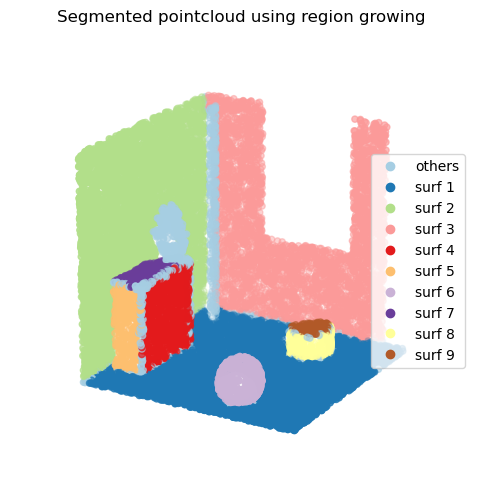

In [7]:
# Segment pointcloud using region growing
regions = region_growing(points, normals, residuals, neighbor_finder,
                         angle_threshold, residual_threshold)    

# Attribute a label to each point (number of attributed region)
labels = np.zeros(len(points))
for i, r in enumerate(regions):
    if len(r) < 100: break # disregard small regions for vizualisation purpose
    labels[r] = i + 1
classes = ["surf {}".format(i) for i in range(len(np.unique(labels)))]
classes[0] = "others"

# Plot segmented pointcloud using region growing
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(points[:, 0], points[:, 1], points[:,2],
               c=labels, cmap="Paired")
ax.legend(loc="right", handles=s.legend_elements()[0], labels=classes)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.view_init(20, 210)
ax.set_title("Segmented pointcloud using region growing")
plt.show()

### The Hough Transform

The Hough Transform is a technique for detecting parametric shapes. Originally introduced for line detection in images \cite{hough1962method}, it was later extended to other 2D shapes, such as circles, and eventually generalized to simple 3D shapes such as planes. Indeed, planar surfaces are ubiquitous in many scenes and detecting more complex shapes quickly becomes computationally expensive, as discussed later.

Rather than searching for shapes directly in the pointcloud, the Hough Transform searches for their parameters. **Each point votes for all compatible parameter values**, and shapes supported by many points appear as peaks in the parameter space.

Since plane detection is the most common application of the Hough Transform in pointcloud processing, let us consider the case of a plane in three-dimensional space. A plane is often described by its Cartesian equation:

\begin{equation*}
    a.x + b.y + c.z + d = 0
\end{equation*}

The first three parameters define the plane orientation through its normal vector $n = [a, b, c]$, while the last $d$ parameter represents its signed distance from the origin.

Using spherical coordinates to express a unit normal vector ($|| n || = 1$) leads to the alternative equation:

\begin{equation*}
    x.\cos(\theta).\sin(\phi) + y.\sin(\theta).\sin(\phi) + z.\cos(\phi) = \rho
\end{equation*}

Although less common, this representation reduces the number of independent parameters from four $(a, b, c, d)$ to three $(\theta, \phi, \rho)$. Moreover, all three parameters lie within finite ranges, including $\rho$, making them well suited for discretization in the Hough Transform. Indeed, if a plane passes through a point $p_{i}$, then $\rho = n \cdot p_{i}$, and by the Cauchy-Schwarz inequality:

\begin{equation*}
    |\rho| = |n \cdot p_i| \leq ||n||.||p_i|| = ||p_i||
\end{equation*}

So, $\rho$ cannot exceed the distance from the origin to the furthest point in the pointcloud. Moreover, the pairs $(\rho, n)$ and $(-\rho, -n)$ describe the same plane. To avoid this redundancy, it is common to restrict $\rho$ to non-negative values.

As a result, planes are usually represented in a three-dimensional Hough space. A point $q_j = [\rho_{j},\theta_{j},\phi_{j}]$ in the Hough space represents the plane $x.\cos(\theta_{j}).\sin(\phi_{j}) + y.\sin(\theta_{j}).\sin(\phi_{j}) +z.\cos(\phi_{j}) = \rho_{j}$ in the original 3D space.

Conversely, a point $p_{i} = [x_i,y_i,z_i]$ in the pointcloud belongs to infinitely many planes. In the Hough space, all planes passing through $p_{i}$ satisfy $ x_{i}.\cos(\theta).\sin(\phi) + y_{i}.\sin(\theta).\sin(\phi) + z_{i}.\cos(\phi) = \rho$, which forms a sinusoidal surface.

The Hough Transform maps every point of the pointcloud into this parameter space, producing one surface per point. Intersections between surfaces correspond to planes shared by the corresponding points. The more surfaces intersect at a given location, the more points belong to the same plane in the original 3D space.

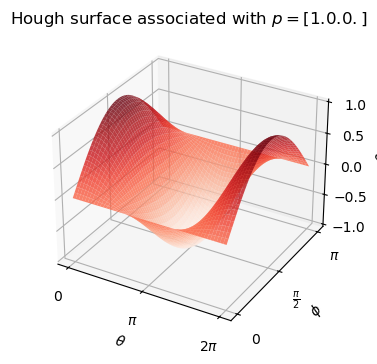

In [8]:
def sample_hough_sinusoid_curve(point, n_theta=50, n_phi=50):
    """Build the unique sinusoid curve in the Hough space for a given point"""

    # Grid with theta and phi
    thetas = np.linspace(0., 2*np.pi, n_theta)
    phis = np.linspace(0., np.pi, n_phi)
    X, Y = np.meshgrid(thetas, phis)
    # Corresponding rho values
    ax = point[0] * np.cos(X) * np.sin(Y)
    by = point[1] * np.sin(X) * np.sin(Y)
    cz = point[2] * np.cos(Y)
    Z = ax + by + cz
    
    return X, Y, Z

# Example with one point
point_hough = np.array([1., 0., 0.])
X, Y, Z = sample_hough_sinusoid_curve(point_hough)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="Reds", alpha=0.8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\phi$')
ax.set_zlabel(r'$\rho$')
ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels([0, r'$\pi$', r'$2\pi$'])
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels([0, r'$\frac{\pi}{2}$', r'$\pi$'])
ax.set_title(f"Hough surface associated with $p={point_hough}$")
plt.show()

Consequently, **plane detection with the Hough Transform consists of finding locations in the Hough space where many sinusoidal surfaces meet**. The more surfaces intersect, the more points belong to the corresponding plane. In practice, however, directly computing these intersections is expensive and sensitive to noise.

To overcome this issue, the Hough space is divided into $n_{\rho} \times n_{\theta} \times n_{\phi}$ cells, called bins. Each bin stores the number of surfaces passing through it, or equivalently, the number of points compatible with the corresponding plane parameters. This discretized space is known as the *accumulator*.

Plane detection can therefore be seen as a **voting process: each point votes for all planes that could pass through it**. Once all votes have been collected, the bins with the highest scores correspond to the most prominent planes in the pointcloud.

The resolution of the accumulator directly affects the results. A finer discretization allows similar planes to be distinguished more easily, but it also increases memory usage and computation time. For example, choosing $n_{\theta} = 360$ and $n_{\phi} = 180$ gives $64\,800 \times n_{\rho}$ bins. A compromise must be found between detection accuracy and computational cost. When memory becomes an issue, smaller integer types or sparse data structures can be used to reduce the size of the accumulator.

In [9]:
def hough_transform_plane(points, n_theta=120, n_phi=61, n_rho=None):
    """Hough Transform for plane detection."""
    
    # Angles at which to compute the transform
    theta_values = np.linspace(0., 2*np.pi, n_theta, endpoint=False) # [0, 2*pi[
    phi_values = np.linspace(0., np.pi, n_phi, endpoint=True) # [0, pi]
    # Compute the bins
    rho_max = np.max(np.linalg.norm(points, axis=1))
    # Unit size by default
    if n_rho is None:
        rho_max = np.ceil(rho_max).astype(int)
        n_rho = rho_max + 1
    rho_values, rho_step = np.linspace(0., rho_max, n_rho, # [0, rho_max]
                                       endpoint=True , retstep=True) 
    # Allocate the accumulator array
    accumulator = np.zeros(
        (n_theta, n_phi, n_rho),
        dtype=np.uint32 # use insigned int
    )
    # Precompute normals to speed-up computation
    i = np.tile(np.arange(n_theta), n_phi) # grid indices for theta
    j = np.repeat(np.arange(n_phi), n_theta) # grid indices for phi
    normals = np.vstack([
        np.cos(theta_values[i]) * np.sin(phi_values[j]),
        np.sin(theta_values[i]) * np.sin(phi_values[j]),
        np.cos(phi_values[j])
    ])
    # Fill accumulator by computing rho values associated with (theta, phi) for each point
    for point in points:
        # Vectorized form of rho = a.x + b.y + c.z
        rho_calc = point @ normals
        # Compute the grid index associted with rho_calc
        k = (rho_calc//rho_step).astype(int)
        # Keep only indices associated with positive rho values (avoid redundancy)
        valid = (k >= 0)
        # Increment bins
        accumulator[i[valid], j[valid], k[valid]] += 1

    return accumulator, theta_values, phi_values, rho_values

In [10]:
def bin_to_plane_parameters(acc_bin, theta_values, phi_values, rho_values):
    """Convert Hough bin indices to plane parameters (a, b, c, d)"""

    theta_idx, phi_idx, rho_idx = acc_bin

    theta = theta_values[theta_idx]
    phi = phi_values[phi_idx]
    rho = rho_values[rho_idx]
    
    a = np.cos(theta) * np.sin(phi)
    b = np.sin(theta) * np.sin(phi)
    c = np.cos(phi)
    d = rho
    
    return np.array([a, b, c, d])


# Transform our pointcloud
accumulator, theta_values, phi_values, rho_values = hough_transform_plane(points)
print(f"The accumulator consists of {accumulator.size} cells,",
      f"of which {np.count_nonzero(accumulator)} are not empty")

# Find the bins with the highest scores
n_best = 5
best_bins = [np.unravel_index(ind, accumulator.shape) 
             for ind in np.argpartition(accumulator.flatten(), -n_best)[-n_best:]]
print(f"The best {n_best} bins are: {[tuple(map(int, bin)) for bin in best_bins]}")

# Retrieve the parameters of the the detected planes
best_planes = [
    bin_to_plane_parameters(b, theta_values, phi_values, rho_values) 
    for b in best_bins
]
with np.printoptions(precision=4, suppress=True):
    print("Detected (cartesian) planes are:", best_planes)


The accumulator consists of 26352000 cells, of which 9532530 are not empty
The best 5 bins are: [(8, 60, 0), (30, 60, 0), (9, 60, 0), (10, 60, 0), (0, 30, 2000)]
Detected (cartesian) planes are: [array([ 0.,  0., -1.,  0.]), array([ 0.,  0., -1.,  0.]), array([ 0.,  0., -1.,  0.]), array([ 0.,  0., -1.,  0.]), array([   1.,    0.,    0., 2000.])]


As shown above, the result is somewhat disappointing, as the detection process returns several nearly identical planes.

These planes correspond to neighboring cells in the accumulator. This can be observed in the figure below, where the detected peaks are grouped into two vertical lines. In this example, the cells with the highest scores correspond to $\rho = 0$ and $\phi = 0$ or $\phi = \pi$. These parameters describe the plane $z=0$. Indeed, when $\phi = 0$ or $\phi = \pi$, the normal vector is aligned with the $z$-axis and the parameter $\theta$ has no influence on the plane equation.

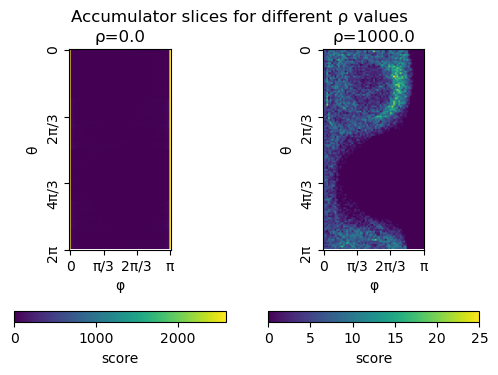

In [11]:
# Show accumulator values for layer rho_index
rho_indices = [0, 1000]

fig, axes = plt.subplots(1, len(rho_indices), figsize=(6, 4))
for ax, rho_index in zip(axes, rho_indices):
    im = ax.imshow(accumulator[:,:,rho_index], cmap='viridis')
    cbar = fig.colorbar(im, ax=ax,
                        location="bottom", orientation="horizontal", pad=0.2)
    cbar.set_label('score')
    ax.set_xticks(np.linspace(0, len(phi_values)-1, 4))
    ax.set_xticklabels(["0", "π/3", "2π/3", "π"], rotation=0)
    ax.set_xlabel('φ')
    ax.set_yticks(np.linspace(0, len(theta_values), 4))
    ax.set_yticklabels(["0", "2π/3", "4π/3", "2π"], rotation=90)
    ax.set_ylabel('θ')
    ax.set_title(f"ρ={rho_values[rho_index]}")
fig.suptitle("Accumulator slices for different ρ values")
plt.show()

The issue described above arises from the parameterization of planes and the presence of a perfectly horizontal plane in the data. In practice, such cases are rare. A simple solution is to retain the accumulator bins with the highest scores and remove duplicate or nearly identical planes.

Number of significant planes (score >= 500): 243
Number of unique significant planes: 5


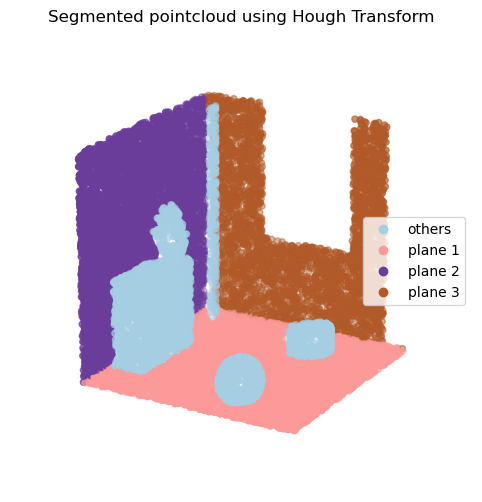

In [12]:
# Find all bins/planes with a score higher than a given threshold
significant_bins = np.argwhere(accumulator >= 500)
significant_planes = [
    bin_to_plane_parameters(b, theta_values, phi_values, rho_values) 
    for b in significant_bins
]
print(f"Number of significant planes (score >= 500): {len(significant_planes)}")

# Remove duplicate planes by rounding parameters and keeping unique rows
significant_planes = np.round(significant_planes, decimals=4)
unique_significant_planes = np.unique(significant_planes, axis=0)
print(f"Number of unique significant planes: {len(unique_significant_planes)}")

# Label each point according to the detected planes
labels = np.zeros(len(points))
for i, plane_equation in enumerate(unique_significant_planes):
    dists = np.abs(points @ plane_equation[:3] - plane_equation[3])
    inliers = dists < 1. # Adjust in function of rho_step
    labels[inliers] = i + 1
classes = ["plane {}".format(i) for i in range(len(np.unique(labels)))]
classes[0] = "others"

# Plot segmented pointcloud using Hough Transform
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(points[:, 0], points[:, 1], points[:,2],
                c=labels, cmap="Paired")
ax.legend(loc="right", handles=s.legend_elements()[0], labels=classes)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.view_init(20, 210)
ax.set_title("Segmented pointcloud using Hough Transform")
plt.show()



The previous example shows that **a single plane often produces several high-score bins in the accumulator**. This can be caused by the parameterization, as illustrated above, but also by discretization and noise. In practice, votes that should fall into the same bin are often spread across neighboring bins.

For this reason, it is generally better to look for groups of neighboring high-score bins rather than simply selecting the bins with the highest scores. A common solution is to **apply Non-Maximum Suppression (NMS) to the accumulator**. The idea is to keep only local maxima and remove lower-scoring bins in their neighborhood.

The simple implementation below first identifies local maxima using a sliding window, then removes peaks whose score is below a given threshold.

In [13]:
def peak_window(accumulator, size_theta=5, size_phi=5, size_rho=3, threshold=None):
    """Use a sliding window technique to filter out the maxima in the accumulator
    that are close to each other."""

    acc = accumulator.copy()
    # Threshold is set to half the max value of the accumulator by default
    if threshold is None:
        threshold = 0.5 * np.max(accumulator)
    # Slide the window and only keep the maximum value
    acc_max = ndimage.maximum_filter(acc, size=(size_theta, size_phi, size_rho),
                                     mode="constant")
    # Create a mask to keep only the peaks
    mask = (acc == acc_max)
    # Apply the mask
    acc *= mask
    # Only keep peaks above the treshold
    acc[acc < threshold] = 0

    return acc


As shown below, small peaks and low-scoring bins are filtered out. However, this only partially addresses the issue of the vertical lines discussed above, since they are formed by several adjacent bins with similarly high scores and therefore remain local maxima.

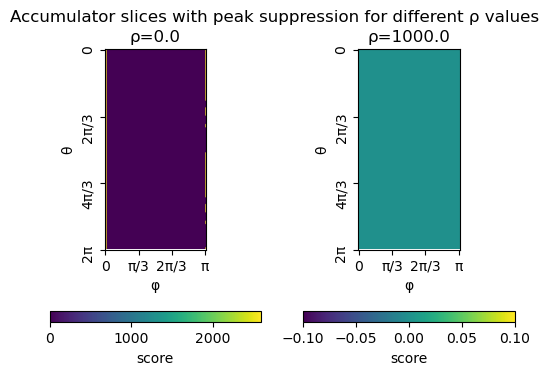

In [14]:
# Apply our peak detection
new_accumulator = peak_window(accumulator)

# Show new accumulator values (with peak suppression) for layer rho_index
# (rho_indices defined above)
fig, axes = plt.subplots(1, len(rho_indices), figsize=(6, 4))
for ax, rho_index in zip(axes, rho_indices):
    im = ax.imshow(new_accumulator[:,:,rho_index], cmap='viridis')
    cbar = fig.colorbar(im, ax=ax,
                        location="bottom", orientation="horizontal", pad=0.2)
    cbar.set_label('score')
    ax.set_xticks(np.linspace(0, len(phi_values)-1, 4))
    ax.set_xticklabels(["0", "π/3", "2π/3", "π"], rotation=0)
    ax.set_xlabel('φ')
    ax.set_yticks(np.linspace(0, len(theta_values), 4))
    ax.set_yticklabels(["0", "2π/3", "4π/3", "2π"], rotation=90)
    ax.set_ylabel('θ')
    ax.set_title(f"ρ={rho_values[rho_index]}")
fig.suptitle("Accumulator slices with peak suppression for different ρ values")
plt.show()

### RANSAC

The Random Sample Consensus (RANSAC) algorithm is a robust model-fitting technique designed to estimate the parameters of a model from data containing noise and outliers. It was originally introduced as a general framework for robust parameter estimation \cite{fischler1981random}.

The algorithm repeatedly performs two simple steps: 

1. **Model generation** by randomly selecting the minimum number of points required to estimate the parameters of a candidate model. 

2. **Model evaluation** by assessing the consistency of all points with the candidate model (e.g., through a distance measure) and counting the number of inliers.

After a given number of iterations, the model with the highest score is retained. The underlying idea is that both model generation and model evaluation are computationally inexpensive, allowing the process to be repeated many times.

In principle, RANSAC can be applied to any model for which these two operations can be defined. In pointcloud processing, it is commonly used to detect geometric primitives such as planes, cylinders, spheres, cones, and tori.

As an example, let us consider the detection of an infinite plane described by the Cartesian equation:
\begin{equation*} 
    a x + b y + c z + d = 0
\end{equation*}

A plane can be uniquely defined by three non-collinear points $p_0$, $p_1$, and $p_2$, from which its parameters are obtained as:
\begin{equation*}
    n = [a,b,c] = (p_1 - p_0) \times (p_2 - p_0) \quad \text{and} \quad d = -p_0 \cdot n
\end{equation*}

Assuming that $n$ is normalized ($||n||=1$), the distance between a point $p$ and the plane is:
\begin{equation*}
    d(p) = |n \cdot p + d|
\end{equation*}

A simple implementation of a plane model suitable for RANSAC is given below.

In [15]:
class PlaneModel:
    """Plane model for RANSAC plane fitting."""

    min_sample_size = 3

    def __init__(self, parameters=None):
        self.parameters = (
            np.array([1., 0., 0., 0.])
            if parameters is None
            else np.asarray(parameters, dtype=float)
        )

    @classmethod
    def from_points(cls, points):
        """Construct a plane from three non-collinear points."""

        n = np.cross(points[1] - points[0], points[2] - points[0])
        n /= np.linalg.norm(n) # May add check for degenerate case
        d = -np.dot(n, points[0])

        return cls([n[0], n[1], n[2], d])

    def compute_distance(self, points):
        """Compute point-to-plane distances."""

        n = self.parameters[:3]
        d = self.parameters[3]

        return np.abs(points @ n + d)


A large number of candidate shapes (here planes) are generated and evaluated before the best one is selected. Points located within a given distance threshold of a candidate shape are considered inliers and contribute to its score. The quality of the segmentation depends on this threshold: strict values may reject valid points, whereas permissive values may include false inliers.

The number of iterations can either be fixed beforehand or determined from a desired confidence level, the latter being preferred in practice because it provides a clear probability of detection rather than relying on an arbitrary number of iterations.

Assuming a pointcloud of $N$ points containing a shape supported by $n$ points, the probability that a random sample of $k$ points (e.g., $k=3$ for a plane) belongs entirely to the shape is approximately $(n/N)^k$ when $N >> k$. After $m$ iterations, the probability of having generated at least one valid candidate is:

\begin{equation*}
    P = 1 - (1 - (\frac{n}{N})^{k})^{m}
\end{equation*}

Solving for $m$ gives the number of candidate models required to detect shapes of size $n$ with a probability $P \geq P_{th}$:
\begin{equation*}
    m \geq \frac{\log(1 - P_{th})}{\log(1 - (\frac{n}{N})^{k})}
\end{equation*}

In practice, the size of the target shape is unknown and the parameter $n$ corresponds to a minimum support $n_{\min}$, ensuring that any shape containing at least $n_{\min}$ points is detected with a probability of at least $P_{th}$.

This highlights one of the main drawbacks of RANSAC: a large number of candidates is often required to achieve a high probability of detection, especially when the shapes of interest represent only a small fraction of the pointcloud. For example, detecting a plane covering only 10\% of the points with a confidence level of 99\% requires several thousand candidate models. To improve efficiency, advanced variants typically reduce the number of samples required to estimate a shape, restrict the set of points used for sampling, and reduce the cost of evaluating each candidate.

For clarity, the RANSAC implementation below follows the basic algorithm and does not include any of the advanced optimizations discussed above.

In [16]:
def RANSAC(points, model, threshold, min_support=1000, confidence=0.99):
    """RANSAC algorithm with confidence-based stopping criterion."""

    N, _ = points.shape
    k = model.min_sample_size

    # Number of iterations required
    n_draws = np.log(1.0 - confidence) / np.log(1.0 - (min_support / N)**k)
    n_draws = int(np.ceil(n_draws))

    best_score = 0
    best_model = None
    best_inliers = None
    for _ in range(n_draws):
        # Random sampling
        sampled_inds = np.random.choice(N, size=k, replace=False)
        sampled_points = points[sampled_inds]
        # Candidate model
        candidate = model.from_points(sampled_points)
        # Inliers
        dists = candidate.compute_distance(points)
        inliers = np.flatnonzero(dists < threshold)
        # Score
        score = len(inliers)
        # Keep best candidate
        if score > best_score:
            best_score = score
            best_model = candidate
            best_inliers = inliers

    return best_model, best_score, best_inliers


The RANSAC algorithm is typically applied iteratively to detect multiple shapes: once a shapes has been detected, its inliers are removed and the process is repeated on the remaining points.

As illustrated below, the algorithm successfully detects the most prominent planar surfaces in the pointcloud.

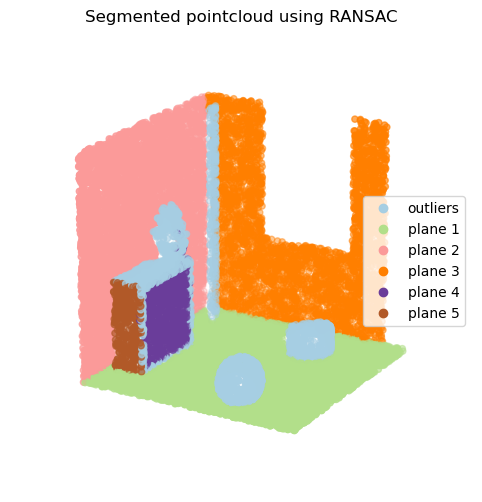

In [21]:
# Run RANSAC for planar surfaces
number_of_shapes = 5

ransac_planes = []
ransac_scores = []
ransac_regions = []
remaining_inds = np.arange(len(points), dtype=int)
for _ in range(number_of_shapes):
    model, score, inliers = RANSAC(
        points[remaining_inds],
        PlaneModel, 
        threshold=1.0,
        min_support=1000,
        confidence=0.99
    )
    ransac_planes.append(model)
    ransac_scores.append(score)
    ransac_regions.append(remaining_inds[inliers])
    remaining_inds = np.setdiff1d(remaining_inds, remaining_inds[inliers])

# Attribute a label to each point (number of attributed region)
labels = np.zeros(len(points))
for i, r in enumerate(ransac_regions):
    labels[r] = i+1
classes = ["plane {}".format(i) for i in range(len(np.unique(labels)))]
classes[0] = "outliers"

# Plot segmented pointcloud using RANSAC
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
              c=labels, cmap="Paired")
ax.legend(loc="right", handles=s.legend_elements()[0], labels=classes)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.view_init(20, 210)
ax.set_title("Segmented pointcloud using RANSAC")
plt.show()


## Object Segmentation

Object segmentation consists of partitioning a pointcloud into distinct regions corresponding to individual objects. The segmentation is typically based on spatial proximity, although additional features may also be used.

The approach presented here relies only on spatial proximity to group points belonging to the same object. In simpler terms, it assumes that points belonging to distinct objects are separated by a sufficient distance. This assumption is usually valid in many environments, including indoor, natural, and urban scenes, where physical entities such as furniture, vegetation, buildings, and vehicles generally exhibit clear spatial boundaries.

One common implementation iteratively groups neighboring points into clusters and can be viewed as a simplified version of the region-growing algorithm described above, using only a proximity criterion and ignoring normal compatibility. Alternatively, **a more direct approach represents the pointcloud as a graph that captures local spatial relationships**. It typically involves two steps:

1. **Graph Construction**: A *nearest neighbors graph* is built, connecting each point to its neighboring points within a given distance or among its $k$ nearest neighbors.

2. **Connected Component Extraction**: Groups of points that are mutually reachable through the graph edges are identified and assumed to represent distinct objects.

The graph construction step is typically accelerated using a data stucture such an octree or a kd-tree (see notebook on *spatial indexing*). The `scipy` library provides an efficient kd-tree implementation, including a `sparse_distance_matrix` method, which can be used to compute a distance matrix between two kd-trees (here the pointcloud kd-tree and itself) while enforcing a maximum neighbor distance. Similarly, `scipy` provides a `connected_components` function for extracting connected components from a sparse graph, eliminating the need for a custom implementation.

Note that **this segmentation method generally requires a preprocessing stage**. In many real-world scenes, objects are connected through a *background* or *support surfaces*. These typically correspond to large horizontal planes such as the ground, floors, or tabletops, but may also include large vertical surfaces such as walls or building facades. If left in the pointcloud, these planes can create connections between otherwise distinct objects, leading to incorrect segmentation results. Consequently, points belonging to support surfaces are often removed beforehand using plane-detection techniques (typically RANSAC-based) or simple height-based filtering methods.

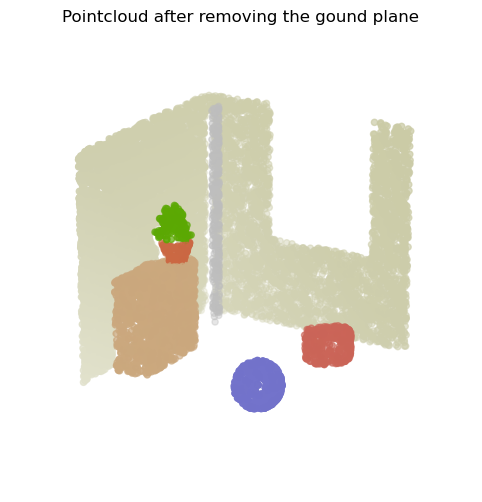

In [18]:
# Remove points belonging to the ground plane (z = 0)
ground_mask = points[:, 2] < 0.05
points_no_ground = points[~ground_mask]
colors_no_ground = colors[~ground_mask]
normals_no_ground = normals[~ground_mask]

# Plot remaining points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(
    points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
    c=colors_no_ground
)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.view_init(20, 210)
ax.set_title("Pointcloud after removing the gound plane")
plt.show()


Despite its apparent simplicity, this technique is capable of segmenting objects in relatively complex scenes. It is computationally efficient and produces easily interpretable results, making it a strong baseline for object segmentation and a widely used approach in practical pointcloud processing pipelines.

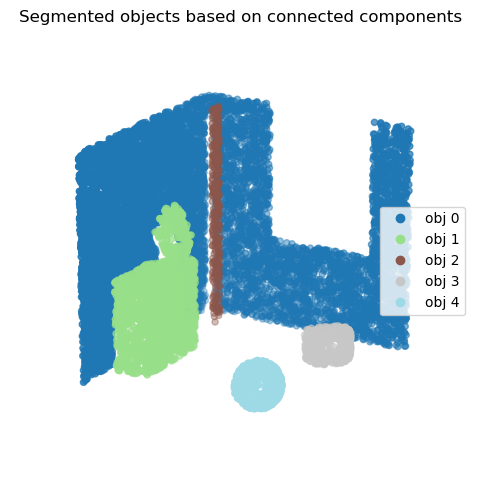

In [19]:
# Find connected components based on euclidean distance
kdtree = KDTree(points_no_ground)
nn_graph = kdtree.sparse_distance_matrix(kdtree, max_distance=100.)
n_components, labels = connected_components(nn_graph, directed=False)

# Plot connected components
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(
    points_no_ground[:, 0], points_no_ground[:, 1], points_no_ground[:, 2],
    c=labels, cmap="tab20"
)
ax.legend(loc="right", handles=s.legend_elements()[0],
          labels=["obj {}".format(i) for i in range(n_components)])
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
ax.view_init(20, 210)
ax.set_title("Segmented objects based on connected components")
plt.show()

## Going further

This section briefly reviews more advanced variants of the segmentation algorithms introduced previously.

### Surface Segmentation

**Region Growing** is simple, deterministic, and particularly effective for extracting smooth surfaces and planar regions. However, its performance depends heavily on local features such as normals, making it sensitive to noise and normal estimation errors.

More advanced variants extend the basic approach with additional constraints, including curvature and color consistency, or region-merging strategies. Another practical extension is *Voxel Cloud Connectivity Segmentation* (VCCS), which first over-segments the pointcloud into spatially coherent *supervoxels* and then performs segmentation on these larger entities rather than on individual points, improving robustness to noise and scalability \cite{papon2013voxel}.

For instance ```PCL``` provides a ```RegionGrowing``` implementation similar to the one presented in this notebook. It also offers ```RegionGrowingRGB```, which uses color similarity instead of normal orientation and includes a post-processing stage where small regions (below a user-defined size threshold) are merged with the closest neighbouring regions. ```PCL``` also implements VCCS through ```SupervoxelClustering```, allowing segmentation to be performed on supervoxels rather than individual points.

The **Hough Transform** segments pointclouds through the detection of parametric shapes, most commonly planes. Its main limitation is computational cost, as performance depends strongly on the discretization of the parameter space.

As a result, numerous variants have been proposed to improve efficiency and robustness for plane detection \cite{borrmann20113d}. These include the *Probabilistic Hough Transform*, which reduces computational cost by randomly sampling a subset of points, or hierarchical accumulator structures that reduce memory requirements. Extending the Hough Transform to more complex 3D shapes is considerably more challenging because the associated parameter spaces become increasingly high-dimensional, resulting in a rapid growth of computational cost and memory requirements, a phenomenon known as the *curse of dimensionality*. In some cases, this limitation can be mitigated through multi-stage parameter estimation, as demonstrated for cylinder detection \cite{rabbani2005efficient}. Nevertheless, such approaches remain relatively uncommon, and the Hough Transform is still used primarily for plane detection.

Despite its long history, the Hough Transform remains relatively uncommon in practical pointcloud processing software, largely because its computational and memory requirements limit its applicability. For instance, ```CloudCompare``` includes a Hough-based plugin for normal estimation rather than plane detection \cite{boulch2012fast}.

**RANSAC** detects and segments parametric shapes in pointclouds through robust model fitting. Its popularity stems from its robustness to outliers and its ability to handle a wide variety of geometric primitives, despite its computational cost and non-deterministic nature.

Many variants have been proposed to improve efficiency and robustness. One of the most influential is *Efficient RANSAC* \cite{schnabel2007efficient}, which improves efficiency through normal-based shape estimation, octree-guided sampling, a multi-criteria scoring function combining distance, normals, and connectivity, and accelerated evaluation based on local sampling and probabilistic early termination. Other notable variants include PROSAC, which prioritizes promising samples, and MSAC and MLESAC, which improve the evaluation of candidate models through alternative scoring functions.

The original implementation of the *Efficient RANSAC* described above is publicly available and has been integrated into ```CGAL``` and distributed in ```CloudCompare``` through a plugin. Open3D provides a simpler ```segment_plane``` implementation that is similar to the one implemented above.

### Object Segmentation

The connected-component approach presented in this notebook is one of the simplest and most widely used methods for object segmentation. The approach can be viewed as a graph-based formulation of *Euclidean clustering*. One main difference is that Euclidean Cluster Extraction usually performs the clustering iteratively through region growing, avoiding the need to store the entire graph.

Another popular technique is *DBSCAN*, a density-based clustering algorithm that groups points according to local point density and can naturally classify isolated points as noise. It is often considered a data-clustering algorithm rather than a purely geometrical segmentation technique, and is covered in a next notebook along with other clustering algorithms such as K-Means.

Other approaches formulate segmentation as a graph-partitioning problem. A notable example is *Min-Cut segmentation*, which partitions a pointcloud into foreground and background regions by minimizing the cost of the removed connections. Unlike proximity-based clustering methods, graph-cut approaches can combine multiple geometric attributes (such as spatial proximity, normals, curvature, or color) and are better suited to separating objects with weak or ambiguous boundaries.

Another family of approaches also relies on *supervoxels*, which first group points into spatially coherent regions and then perform segmentation on the resulting adjacency graph \cite{papon2013voxel}. Operating on supervoxels rather than individual points generally improves scalability and robustness while preserving object boundaries more effectively.

Implementations of Euclidean clustering, Min-Cut segmentation, and VCCS are available in ```PCL``` through ```EuclideanClusterExtraction```, ```MinCutSegmentation```, and ```SupervoxelClustering```, respectively.

## Wrapping up

You should now have a better grasp of some of the most popular surface segmentation algorithms: Region Growing, the Hough Transform, and RANSAC. These approaches rely only on geometrical reasoning and *a priori* assumptions about surfaces to detect: Region Growing groups points that belong to locally smooth surfaces, while the Hough Transform and RANSAC identify geometric primitives.

In practice, the choice of algorithm depends on the application. **Region Growing is well suited to extracting smooth surfaces** from dense and relatively clean pointclouds because it operates locally. The Hough Transform is useful for detecting planar shapes but is not often used in practice because it relies on discretizing the shape parameter space, which can lead to significant computational and memory costs. **RANSAC** is often preferred because it **can detect many types of parametric shapes** and is robust to noise and outliers. However, it is non-deterministic, can be computationally expensive due to its iterative nature, and may require careful parameter tuning.

Surface segmentation can also be used to remove less relevant parts of a pointcloud, such as *background* or *support surfaces*, as a first step toward object segmentation. A common approach is to group points based on proximity using nearest-neighbor graphs and connected-component analysis.

A key takeaway is that all these algorithms require an extensive phase of manual tuning and produce imperfect results on complex pointclouds. This is because they rely on relatively simple assumptions about the scene and on prior knowledge of pointcloud properties such as density and noise levels. Despite these limitations, the results are often good enough for later processing steps. In practice, some manual correction is usually needed.

These limitations partly explain the recent shift from traditional geometry-based segmentation methods to machine-learning and deep-learning approaches. Learning-based methods can segment and classify points using more global and abstract features. This topic will be covered in a future notebook. Before that, the next chapter introduces surface fitting, that is, estimating the parameters of segmented surfaces.